In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [ ]:
historical_df = pd.read_csv(r'C:\Users\rishi\Downloads\Primetrade\historical_data.csv')
sentiment_df = pd.read_csv(r'C:\Users\rishi\Downloads\Primetrade\fear_greed_index.csv')

In [4]:
historical_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
historical_df.tail()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,382.2,420.80,SELL,25-04-2025 15:35,7546.6,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,2124.1,2338.63,SELL,25-04-2025 15:35,7164.4,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,423.4,466.16,SELL,25-04-2025 15:35,5040.3,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,3599.8,3963.38,SELL,25-04-2025 15:35,4616.9,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12
211223,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,1017.1,1119.83,SELL,25-04-2025 15:35,1017.1,Close Long,-53.9063,0xac77fab973c455d77a670422374d9602039800f1f78c...,88803313862,False,0.111982,3.270000e+14,1.750000e+12


In [6]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
sentiment_df.tail()

,timestamp,value,classification,date
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01
2643,1746163800,67,Greed,2025-05-02


In [8]:
print(f"Historical Data Shape: {historical_df.shape}")
print(f"Sentiment Data Shape: {sentiment_df.shape}\n")

Historical Data Shape: (211224, 16)
Sentiment Data Shape: (2644, 4)



In [9]:
historical_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [10]:
sentiment_df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [11]:
historical_df['Timestamp IST'] = pd.to_datetime(historical_df['Timestamp IST'], dayfirst=True)
historical_df['join_date'] = historical_df['Timestamp IST'].dt.strftime('%Y-%m-%d')

In [12]:
historical_df.sample()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,join_date
132248,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,LDO,1.8671,6.2,11.58,SELL,2024-12-03 12:47:00,-80.1,Open Short,0.0,0x08d5d6de2796af6a7fa704184d387f01e500626184bb...,52172398663,True,0.004051,8.570000e+14,1.730000e+12,2024-12-03


In [13]:
sentiment_df['join_date'] = pd.to_datetime(sentiment_df['date']).dt.strftime('%Y-%m-%d')


In [14]:
sentiment_df.sample()

,timestamp,value,classification,date,join_date
316,1545024600,17,Extreme Fear,2018-12-17,2018-12-17


In [15]:
historical_df['Closed PnL'] = pd.to_numeric(historical_df['Closed PnL'], errors='coerce').fillna(0)
historical_df['Size USD'] = pd.to_numeric(historical_df['Size USD'], errors='coerce').fillna(0)

In [16]:
merged_df = pd.merge(historical_df, sentiment_df, on='join_date', how='inner')
print(f"Merged Analysis Data Shape: {merged_df.shape}\n")

Merged Analysis Data Shape: (211218, 21)



In [17]:
print("Performance Summary by Market Sentiment")
performance_summary = merged_df.groupby('classification').agg(
    total_pnl=('Closed PnL', 'sum'),
    average_pnl=('Closed PnL', 'mean'),
    average_trade_size=('Size USD', 'mean'),
    total_trades=('Closed PnL', 'count')
).reset_index()
print(performance_summary.to_string(index=False))

Performance Summary by Market Sentiment
classification    total_pnl  average_pnl  average_trade_size  total_trades
  Extreme Fear 7.391102e+05    34.537862         5349.731843         21400
 Extreme Greed 2.715171e+06    67.892861         3112.251565         39992
          Fear 3.357155e+06    54.290400         7816.109931         61837
         Greed 2.150129e+06    42.743559         5736.884375         50303
       Neutral 1.292921e+06    34.307718         4782.732661         37686


- In Fear, traders made the most money overall (highest total profit ~3.35M) and also had the biggest average trade size.

- In Extreme Greed, traders earned solid profits (~2.71M) with smaller trade sizes but still good average gains per trade.

- In Greed, profits were lower (~2.15M) compared to Fear and Extreme Greed, but trade activity was still high.

- In Neutral and Extreme Fear, profits were the smallest (~1.29M and ~0.74M), showing that traders struggled more in calm or very fearful markets.

- Fear → most profitable overall, big trades.

- Extreme Greed → strong profits, smaller trades but good average wins.

- Greed → moderate profits, steady activity.

- Neutral & Extreme Fear → weakest profits, tougher conditions.

In [18]:
print("Win Rate Analysis by Market Sentiment")
realized_trades = merged_df[merged_df['Closed PnL'] != 0].copy()
realized_trades['is_win'] = realized_trades['Closed PnL'] > 0

win_rate_summary = realized_trades.groupby('classification').agg(
    winning_trades=('is_win', 'sum'),
    total_closed_trades=('is_win', 'count'),
    win_rate=('is_win', 'mean')
).reset_index()
win_rate_summary['win_rate (%)'] = (win_rate_summary['win_rate'] * 100).round(2)
print(win_rate_summary[['classification', 'total_closed_trades', 'winning_trades', 'win_rate (%)']].to_string(index=False))

Win Rate Analysis by Market Sentiment
classification  total_closed_trades  winning_trades  win_rate (%)
  Extreme Fear                10406            7931         76.22
 Extreme Greed                20853           18594         89.17
          Fear                29808           26019         87.29
         Greed                25176           19358         76.89
       Neutral                18159           14961         82.39


- In Extreme Greed, traders win almost all the time — nearly 9 out of 10 trades succeed.

- In Fear, win rates are also very high (87%), showing traders handle fearful markets well.

- In Neutral conditions, success is steady (82%) but not as strong as Fear or Extreme Greed.

- In Greed and Extreme Fear, win rates drop to around 76–77%, meaning traders struggle more when the market is overly confident or very panicked.

- Best performance → Extreme Greed & Fear.

- Moderate performance → Neutral.

- Weakest performance → Extreme Fear & Greed.

In [19]:
print("Directional Bias (Long vs Short)")
directional_bias = pd.crosstab(merged_df['classification'], merged_df['Side'], normalize='index') * 100
print(directional_bias.round(2))

Directional Bias (Long vs Short)
Side              BUY   SELL
classification              
Extreme Fear    51.10  48.90
Extreme Greed   44.86  55.14
Fear            48.95  51.05
Greed           48.86  51.14
Neutral         50.33  49.67


- In Extreme Fear, traders lean slightly more toward buying (51%) — likely seeing bargains when the market is panicking.

- In Extreme Greed, the bias flips — selling dominates (55%) as traders lock in profits when optimism runs high.

- In Fear and Greed, selling edges out buying by a small margin (around 51%), showing cautious behavior.

- In Neutral markets, buying and selling are almost perfectly balanced (50/50).

- Extreme Fear → more buying (bargain hunting).

- Extreme Greed → more selling (profit-taking).

- Fear & Greed → slight selling bias.

- Neutral → balanced trading.

C:\Users\ruler\AppData\Local\Temp\ipykernel_716\321977473.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


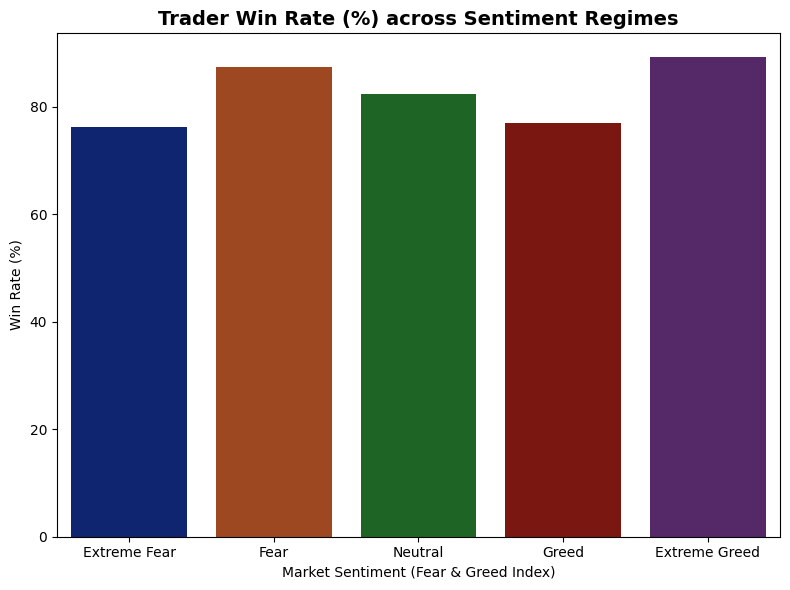

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    data=win_rate_summary, 
    x='classification', 
    y='win_rate (%)', 
    ax=ax, 
    palette='dark',
    order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
)
ax.set_title('Trader Win Rate (%) across Sentiment Regimes', fontsize=14, fontweight='bold')
ax.set_xlabel('Market Sentiment (Fear & Greed Index)')
ax.set_ylabel('Win Rate (%)')

plt.tight_layout()
plt.show()


Traders tend to do better when the market is either very greedy or fearful. In those times, win rates are higher because the market moves more clearly, making it easier to spot good opportunities. On the other hand, when the market is extremely fearful or just greedy, traders struggle more emotions and uncertainty make it harder to succeed. Neutral times sit in the middle, steady but not as profitable.
- Traders win most when the crowd is panicking (Fear) or chasing gains (Extreme Greed).

- They win less when the market is shaky (Extreme Fear) or overconfident (Greed).

- Neutral markets are balanced — not too risky, not too rewarding.

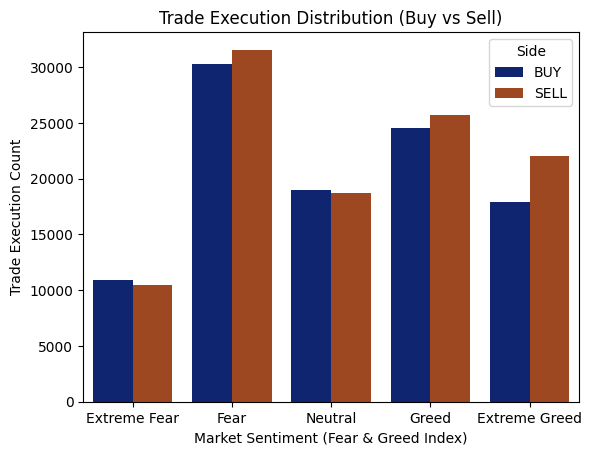

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
sns.countplot(data=merged_df, x='classification', hue='Side', ax=ax,palette='dark',order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])
plt.title('Trade Execution Distribution (Buy vs Sell)')
plt.xlabel('Market Sentiment (Fear & Greed Index)')
plt.ylabel('Trade Execution Count')

plt.show()


When the market is in Extreme Fear, people tend to buy more — probably because prices look cheap and traders see opportunities. But in Fear and Greed phases, selling slightly outweighs buying, showing that traders are more cautious or locking in profits. In Neutral times, activity is balanced, while in Extreme Greed, buying and selling are both strong, reflecting high confidence and heavy participation.

- Extreme Fear → more buying (bargain hunting).

- Fear & Greed → more selling (profit-taking, caution).

- Neutral → balanced trades.

- Extreme Greed → busy market, both sides active.